# 5. Quantum Simulation & Comparative Analysis

In this notebook we:
1. Load our various model checkpoints from the pipeline:
   - **Initial** (../checkpoints)
   - **Quantized** (../checkpoints/model_quantized)
   - **LoRA Finetuned** (../checkpoints/model_lora)
   - **Pruned** (../checkpoints/model_pruned)

2. For each checkpoint we:
   - Evaluate classical performance (inference time, model size) on a sample prompt.
   - **Apply a simulated quantum transformation** to the model (a quantum‐inspired weight perturbation),
     re‐evaluate inference performance, and compare it to the classical one.

3. Visualize and compare the metrics (size and inference latency) for the classical versus quantum-simulated models.

**Note:** The “quantum AI simulation” step is implemented by a function that applies a simple quantum-inspired transformation:
for each Linear layer the weight is adjusted by a small random “unitary‐like” perturbation.

**Reminders:**
- The models load in low precision (float16) and use the proper device (MPS > CUDA > CPU).
- All checkpoints and metrics are saved for further analysis.


In [1]:
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import json

from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_from_disk

# Disable tokenizers parallelism to avoid fork warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set seed for reproducibility
set_seed(42)


## 1. Define Checkpoint Directories & Helper Functions

In [2]:
# Define directories for the various checkpoints
checkpoint_dirs = {
    "Initial": "../checkpoints/initial_model",
    "Quantized": "../checkpoints/model_quantized",
    "LoRA Finetuned": "../checkpoints/model_lora",
    "Pruned": "../checkpoints/model_pruned"
}

def get_device():
    """Select device: Prefer MPS (Apple Silicon), then CUDA, else CPU."""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Device Selected: MPS (Apple Silicon)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Device Selected: CUDA")
    else:
        device = torch.device("cpu")
        print("Device Selected: CPU")
    return device

device = get_device()

def get_folder_size(directory):
    """Return folder size (in MB) by summing file sizes recursively."""
    total_size = 0
    for dirpath, _, filenames in os.walk(directory):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)  # Convert bytes to MB


Device Selected: MPS (Apple Silicon)


## 2. Load a Sample from the Dataset

We load the WikiText-2 dataset (saved in ../data/wikitext-2), filter out empty examples, and select a representative prompt.


In [3]:
DATASET_DIR = "../data/wikitext-2"
print("Loading dataset from:", DATASET_DIR)
try:
    dataset = load_from_disk(DATASET_DIR)
    train_dataset = dataset["train"]
    # Remove empty examples to avoid processing issues
    train_dataset = train_dataset.filter(lambda x: len(x["text"].strip()) > 0)
    print(f"Number of training examples after filtering: {len(train_dataset)}")
except Exception as e:
    print("Error loading dataset:", e)
    raise

# Select a sample prompt (first 200 characters for demonstration)
sample_prompt = train_dataset[0]["text"][:200]
print("Sample Prompt:")
print(sample_prompt)


Loading dataset from: ../data/wikitext-2
Number of training examples after filtering: 23767
Sample Prompt:
 = Valkyria Chronicles III = 




## 3. Define Evaluation Functions

We define two key functions:
1. `evaluate_model`: Loads a model from a checkpoint, tokenizes the prompt, and records average inference time and checkpoint size.
2. `simulate_quantum_model`: Applies a simulated quantum transformation to the model's Linear layers.


In [4]:
def evaluate_model(checkpoint_path, num_runs=5, max_new_tokens=20):
    """
    Evaluate the model classically from a given checkpoint.
    Returns the average inference time (seconds) and model size (MB).
    """
    try:
        model = AutoModelForCausalLM.from_pretrained(
            checkpoint_path,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True
        )
        tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model.to(device)
    except Exception as e:
        print(f"Error loading model from {checkpoint_path}: {e}")
        return None, None

    inputs = tokenizer(sample_prompt, return_tensors="pt").to(device)
    _ = model.generate(**inputs, max_new_tokens=max_new_tokens)  # Warm-up

    times = []
    for i in range(num_runs):
        start_time = time.time()
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - start_time)
    avg_time = np.mean(times)
    model_size = get_folder_size(checkpoint_path)
    return avg_time, model_size

def simulate_quantum_model(model):
    """
    Apply a simulated quantum transformation to the model.
    For each Linear layer, we add a small unitary-inspired perturbation.
    (For demonstration, new_weight = weight + epsilon * noise.)
    """
    epsilon = 0.01  # Small perturbation factor
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            with torch.no_grad():
                noise = epsilon * torch.randn_like(module.weight)
                module.weight.data = module.weight.data + noise
    return model

def evaluate_quantum_model(checkpoint_path, num_runs=5, max_new_tokens=20):
    """
    Evaluate the "quantum-simulated" version of a model.
    Loads the model, applies the quantum simulation transformation, then evaluates inference time.
    Returns the average inference time (seconds) and model size remains the same as the original checkpoint.
    """
    try:
        model = AutoModelForCausalLM.from_pretrained(
            checkpoint_path,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True
        )
        tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model.to(device)
    except Exception as e:
        print(f"Error loading model from {checkpoint_path}: {e}")
        return None, None

    # Apply the quantum-inspired transformation
    model = simulate_quantum_model(model)
    
    inputs = tokenizer(sample_prompt, return_tensors="pt").to(device)
    _ = model.generate(**inputs, max_new_tokens=max_new_tokens)  # Warm-up
    
    times = []
    for i in range(num_runs):
        start_time = time.time()
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - start_time)
    avg_time = np.mean(times)
    # We use the same checkpoint size (quantum simulation does not change file size)
    model_size = get_folder_size(checkpoint_path)
    return avg_time, model_size


## 4. Evaluate Classical and Quantum-Simulated Models for Each Checkpoint

For each checkpoint model, we compute:
- Classical average inference time and model size.
- Quantum-simulated inference time after transformation.
Results are stored in separate dictionaries.

In [5]:
classical_results = {}
quantum_results = {}

for stage, path in checkpoint_dirs.items():
    print(f"\nEvaluating checkpoint: {stage}")
    avg_time_classical, size_mb = evaluate_model(path)
    avg_time_quantum, _ = evaluate_quantum_model(path)
    
    if avg_time_classical is not None and size_mb is not None:
        classical_results[stage] = {"inference_time": avg_time_classical, "model_size": size_mb}
        quantum_results[stage] = {"inference_time": avg_time_quantum, "model_size": size_mb}  # same size assumed
        
        print(f"Classical - Avg Inference Time: {avg_time_classical:.3f} s, Size: {size_mb:.1f} MB")
        print(f"Quantum-Simulated - Avg Inference Time: {avg_time_quantum:.3f} s")
    else:
        classical_results[stage] = {"inference_time": None, "model_size": None}
        quantum_results[stage] = {"inference_time": None, "model_size": None}


Evaluating checkpoint: Initial


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/Users/swayamsingal/transformers/src/transformers/pytorch_utils.py:328: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_i

Classical - Avg Inference Time: 0.376 s, Size: 242.0 MB
Quantum-Simulated - Avg Inference Time: 0.366 s

Evaluating checkpoint: Quantized


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassific

Classical - Avg Inference Time: 0.404 s, Size: 242.0 MB
Quantum-Simulated - Avg Inference Time: 0.448 s

Evaluating checkpoint: LoRA Finetuned
'NoneType' object has no attribute 'cadam32bit_grad_fp32'


/Users/swayamsingal/miniconda3/envs/research_env/lib/python3.10/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadM

Classical - Avg Inference Time: 0.457 s, Size: 260.3 MB
Quantum-Simulated - Avg Inference Time: 0.474 s

Evaluating checkpoint: Pruned


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassific

Classical - Avg Inference Time: 0.457 s, Size: 243.1 MB
Quantum-Simulated - Avg Inference Time: 0.492 s


## 5. Visualization & Comparative Analysis

We now produce side-by-side bar charts comparing:
- Model size (which remains the same for classical vs. quantum).
- Average inference times (classical vs. quantum-simulated) for each checkpoint.

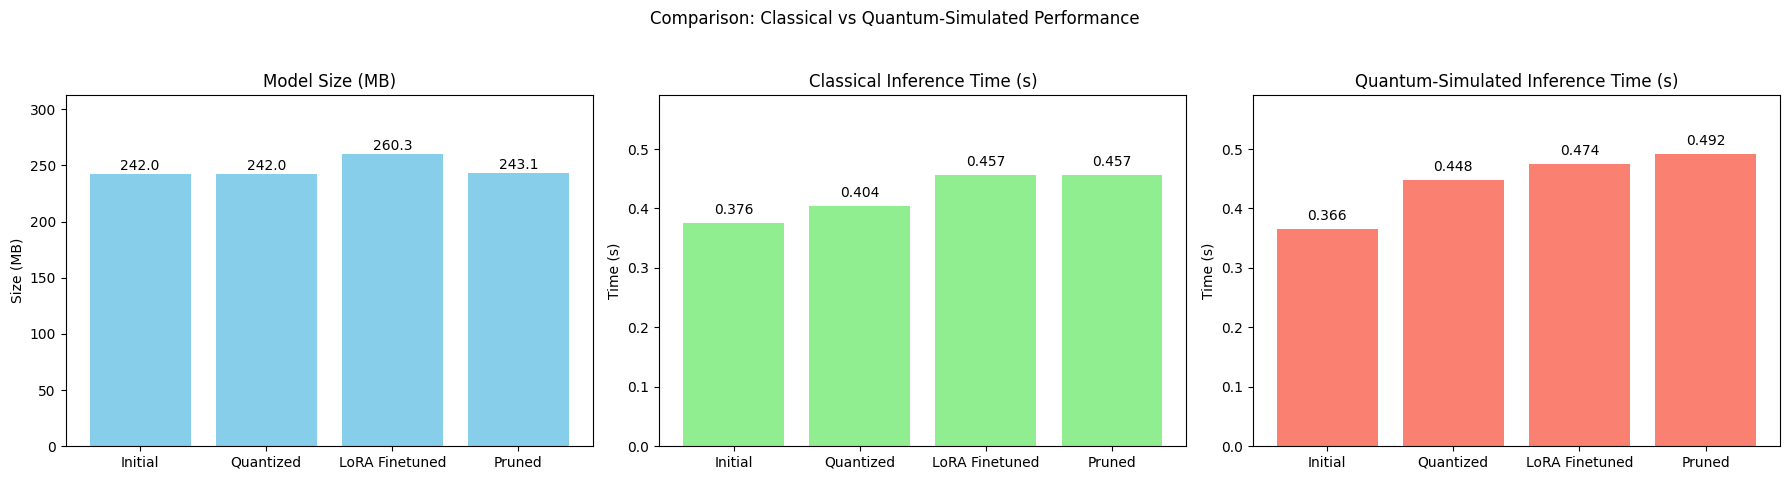

In [6]:
stages = list(classical_results.keys())
classical_times = [classical_results[stage]["inference_time"] for stage in stages]
quantum_times = [quantum_results[stage]["inference_time"] for stage in stages]
sizes = [classical_results[stage]["model_size"] for stage in stages]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Model Sizes (classical and quantum are the same)
axes[0].bar(stages, sizes, color="skyblue")
axes[0].set_title("Model Size (MB)")
axes[0].set_ylabel("Size (MB)")
axes[0].set_ylim(0, max(sizes)*1.2)
for i, val in enumerate(sizes):
    axes[0].text(i, val + 1, f"{val:.1f}", ha="center", va="bottom")

# Plot Classical Inference Times
axes[1].bar(stages, classical_times, color="lightgreen")
axes[1].set_title("Classical Inference Time (s)")
axes[1].set_ylabel("Time (s)")
axes[1].set_ylim(0, max(classical_times + quantum_times)*1.2)
for i, val in enumerate(classical_times):
    axes[1].text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom")

# Plot Quantum-Simulated Inference Times
axes[2].bar(stages, quantum_times, color="salmon")
axes[2].set_title("Quantum-Simulated Inference Time (s)")
axes[2].set_ylabel("Time (s)")
axes[2].set_ylim(0, max(classical_times + quantum_times)*1.2)
for i, val in enumerate(quantum_times):
    axes[2].text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom")

plt.suptitle("Comparison: Classical vs Quantum-Simulated Performance")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 6. Save the Comparative Analysis Results

We also save the classical and quantum-simulated performance metrics into a JSON file for future reference.

In [8]:
analysis_output_dir = "../checkpoints/analysis"
os.makedirs(analysis_output_dir, exist_ok=True)
output_file = os.path.join(analysis_output_dir, "comparative_performance_metrics.json")

comparison_results = {
    "classical": classical_results,
    "quantum": quantum_results
}

with open(output_file, "w") as f:
    json.dump(comparison_results, f, indent=4)
print(f"Comparative performance metrics saved to {output_file}")

Comparative performance metrics saved to ../checkpoints/analysis/comparative_performance_metrics.json


## Completion Message

The Quantum Simulation & Comparative Analysis notebook has:
- Evaluated both classical and quantum-simulated performance for each checkpoint.
- Produced visualization comparing model sizes and inference times.
- Saved the comparative results for further review.

In [9]:
print("Quantum simulation & comparative analysis complete.")

Quantum simulation & comparative analysis complete.
